# Tugas Praktikum 2: Praproses Data
## House Prices - Advanced Regression Techniques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

df.info()

Jumlah baris : 1460
Jumlah kolom : 81
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-n

## 2. Pembersihan Data

Pada tahap ini dilakukan pemeriksaan nilai yang hilang (missing value) pada setiap atribut. Atribut dengan proporsi missing value lebih dari 50% akan dihapus, sedangkan missing value yang masih tersisa akan ditangani sesuai dengan tipe datanya.

In [4]:
missing_data = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Jumlah Missing'] > 0]
missing_data = missing_data.sort_values('Persentase (%)', ascending=False)

missing_data

,Jumlah Missing,Persentase (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [5]:
kolom_hapus = missing_data[
    missing_data['Persentase (%)'] > 50
].index.tolist()

print("Atribut dengan missing value > 50%:")
print(kolom_hapus)

Atribut dengan missing value > 50%:
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


In [6]:
df = df.drop(columns=kolom_hapus)

print("Jumlah atribut setelah penghapusan:", df.shape[1])

Jumlah atribut setelah penghapusan: 76


In [7]:
kolom_none = [
    'FireplaceQu',
    'GarageType', 'GarageYrBlt', 'GarageFinish',
    'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'BsmtQual', 'BsmtCond'
]

for kolom in kolom_none:
    if kolom != 'GarageYrBlt':
        df[kolom] = df[kolom].fillna('None')

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())

df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [8]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [9]:
print("Total missing value setelah pembersihan:", df.isnull().sum().sum())

df.isnull().sum()[df.isnull().sum() > 0]

Total missing value setelah pembersihan: 0


Series([], dtype: int64)

## 3. Deteksi dan Penanganan Outlier

Outlier pada atribut numerik dideteksi menggunakan metode Interquartile Range (IQR) dan divisualisasikan menggunakan boxplot. Deteksi dilakukan untuk mengetahui nilai yang berada jauh di luar rentang mayoritas data sebelum menentukan metode penanganan yang sesuai.

In [10]:
kolom_numerik = df.select_dtypes(include=np.number).columns.drop('Id')

print("Jumlah atribut numerik:", len(kolom_numerik))

Jumlah atribut numerik: 37


In [11]:
hasil_outlier = []

for kolom in kolom_numerik:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    jumlah_outlier = (
        (df[kolom] < batas_bawah) |
        (df[kolom] > batas_atas)
    ).sum()

    hasil_outlier.append([kolom, jumlah_outlier])

outlier_df = pd.DataFrame(
    hasil_outlier,
    columns=['Atribut', 'Jumlah Outlier']
)

outlier_df = outlier_df[outlier_df['Jumlah Outlier'] > 0]
outlier_df = outlier_df.sort_values('Jumlah Outlier', ascending=False)

outlier_df

,Atribut,Jumlah Outlier
29,EnclosedPorch,208
9,BsmtFinSF2,167
4,OverallCond,125
31,ScreenPorch,116
0,MSSubClass,103
7,MasVnrArea,98
1,LotFrontage,93
17,BsmtHalfBath,82
28,OpenPorchSF,77
2,LotArea,69


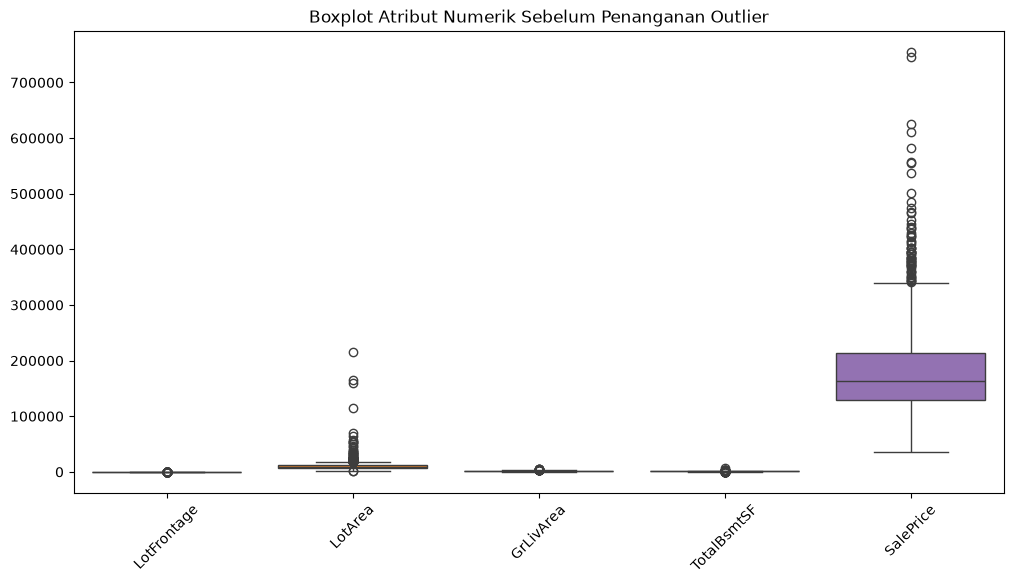

In [12]:
kolom_boxplot = [
    'LotFrontage',
    'LotArea',
    'GrLivArea',
    'TotalBsmtSF',
    'SalePrice'
]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[kolom_boxplot])
plt.title('Boxplot Atribut Numerik Sebelum Penanganan Outlier')
plt.xticks(rotation=45)
plt.show()

Berdasarkan boxplot, terdapat sejumlah nilai yang berada di luar whisker pada beberapa atribut numerik. Nilai tersebut tidak langsung dihapus karena dapat merepresentasikan karakteristik rumah yang memang berbeda dari mayoritas data. Penanganan dilakukan menggunakan metode IQR capping agar pengaruh nilai ekstrem dapat dikurangi tanpa menghilangkan observasi dari dataset.

In [13]:
kolom_capping = [
    'LotFrontage',
    'LotArea',
    'GrLivArea',
    'TotalBsmtSF',
    'SalePrice'
]

for kolom in kolom_capping:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    df[kolom] = df[kolom].clip(
        lower=batas_bawah,
        upper=batas_atas
    )

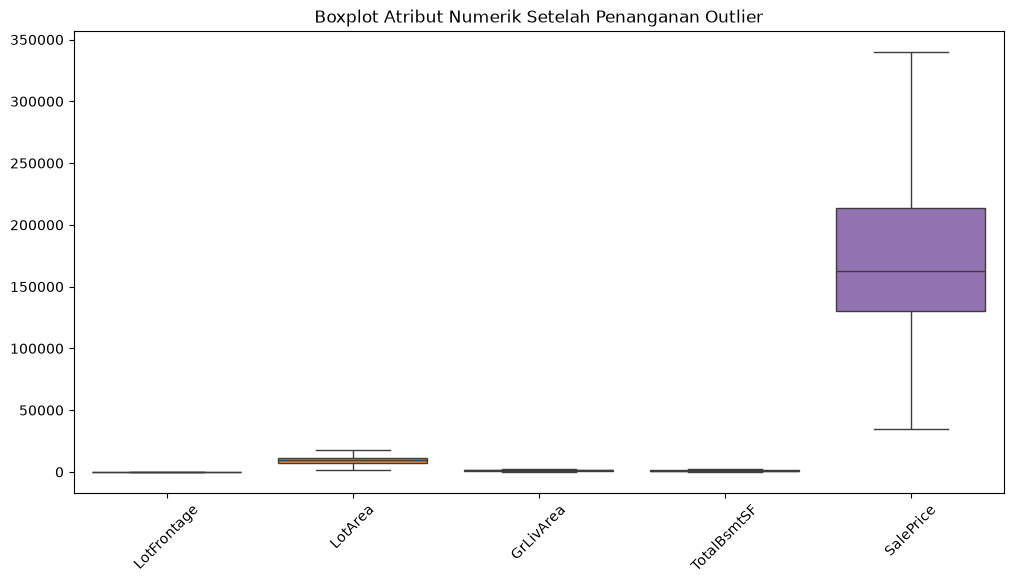

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[kolom_capping])
plt.title('Boxplot Atribut Numerik Setelah Penanganan Outlier')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Menyimpan dataset hasil cleaning
df_clean = df.copy()

df_clean.to_csv(
    '5054251018_Dinnetza Araafya Yudetti_Tugas_Praproses_Data.csv',
    index=False
)

print("Dataset hasil cleaning berhasil disimpan.")
print("Ukuran dataset:", df_clean.shape)
print("Total missing value:", df_clean.isnull().sum().sum())

Dataset hasil cleaning berhasil disimpan.
Ukuran dataset: (1460, 76)
Total missing value: 0


## 4. Transformasi Data

Transformasi data dilakukan agar atribut memiliki format dan skala yang sesuai untuk proses analisis. Atribut numerik distandarisasi menggunakan StandardScaler, sedangkan atribut kategoris diubah menjadi bentuk numerik menggunakan one-hot encoding.

In [19]:
fitur_numerik = df.select_dtypes(include=np.number).columns.tolist()

fitur_numerik.remove('Id')
fitur_numerik.remove('SalePrice')

scaler = StandardScaler()
df[fitur_numerik] = scaler.fit_transform(df[fitur_numerik])

df[fitur_numerik].head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.073375,-0.249286,-0.333244,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,-0.288653,...,0.351000,-0.752176,0.216503,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,0.138777
1,-0.872563,0.583251,-0.013189,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,-0.288653,...,-0.060731,1.626195,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.489110,-0.614439
2,0.073375,-0.082779,0.446022,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,-0.288653,...,0.631726,-0.752176,-0.070361,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.990891,0.138777
3,0.309859,-0.526798,-0.027104,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,-0.288653,...,0.790804,-0.752176,-0.176048,4.092524,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,-1.367655
4,0.073375,0.805261,1.283733,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,-0.288653,...,1.698485,0.780197,0.563760,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,2.100892,0.138777


In [20]:
df[fitur_numerik].describe().loc[['mean', 'std']]

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
mean,-8.455945e-17,1.812857e-16,5.535907e-17,1.387018e-16,3.540547e-16,1.046347e-15,4.496860e-15,-3.893385e-17,-2.433366e-17,-3.406712e-17,...,-1.216683e-17,5.596741e-17,3.041707e-17,-2.311697e-17,4.866731e-18,5.475072e-17,1.946692e-17,-2.676702e-17,7.543433e-17,3.567436e-14
std,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,...,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00


In [21]:
fitur_kategoris = df.select_dtypes(include='object').columns.tolist()

print("Jumlah atribut kategoris:", len(fitur_kategoris))
print(fitur_kategoris)

Jumlah atribut kategoris: 38
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


C:\Users\Araafya\AppData\Local\Temp\ipykernel_30464\2888410053.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  fitur_kategoris = df.select_dtypes(include='object').columns.tolist()


In [22]:
df_encoded = pd.get_dummies(
    df,
    columns=fitur_kategoris,
    drop_first=True,
    dtype=int
)

print("Ukuran sebelum encoding:", df.shape)
print("Ukuran setelah encoding :", df_encoded.shape)

Ukuran sebelum encoding: (1460, 76)
Ukuran setelah encoding : (1460, 245)


In [23]:
df_encoded.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,0.073375,-0.249286,-0.333244,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,...,0,0,0,0,1,0,0,0,1,0
1,2,-0.872563,0.583251,-0.013189,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,...,0,0,0,0,1,0,0,0,1,0
2,3,0.073375,-0.082779,0.446022,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,...,0,0,0,0,1,0,0,0,1,0
3,4,0.309859,-0.526798,-0.027104,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,...,0,0,0,0,1,0,0,0,0,0
4,5,0.073375,0.805261,1.283733,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,...,0,0,0,0,1,0,0,0,1,0


## 5. Reduksi Dimensi

Reduksi dimensi dilakukan untuk mengurangi jumlah atribut yang memiliki informasi redundan. Tahap pertama dilakukan menggunakan analisis korelasi untuk mengidentifikasi atribut yang memiliki hubungan sangat kuat, kemudian PCA digunakan untuk mereduksi jumlah dimensi dengan tetap mempertahankan sebagian besar informasi pada data.

In [24]:
X = df_encoded.drop(columns=['Id', 'SalePrice'])
y = df_encoded['SalePrice']

# Menghitung matriks korelasi antarfitur
corr_matrix = X.corr().abs()

corr_matrix

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
MSSubClass,1.000000,0.409947,0.395878,0.032628,0.059316,0.027850,0.040581,0.023573,0.069836,0.065649,...,0.001244,0.014005,0.045156,0.014555,0.026359,0.016241,0.030002,0.000983,0.024359,0.051068
LotFrontage,0.409947,1.000000,0.618181,0.247068,0.047256,0.142360,0.078215,0.222590,0.177738,0.060814,...,0.014018,0.061465,0.120552,0.027262,0.094130,0.043612,0.019536,0.001037,0.064220,0.119030
LotArea,0.395878,0.618181,1.000000,0.221454,0.018512,0.065671,0.054472,0.159452,0.221582,0.094716,...,0.017173,0.027582,0.072297,0.004909,0.049043,0.023995,0.011011,0.001421,0.032991,0.076044
OverallQual,0.032628,0.247068,0.221454,1.000000,0.091932,0.572323,0.550684,0.407252,0.239666,0.059119,...,0.004269,0.021172,0.327412,0.057962,0.225013,0.041677,0.044950,0.025515,0.143282,0.323295
OverallCond,0.059316,0.047256,0.018512,0.091932,1.000000,0.375983,0.073741,0.125694,0.046231,0.040229,...,0.001299,0.019779,0.156175,0.050663,0.163684,0.038888,0.033444,0.023873,0.161642,0.151659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SaleCondition_AdjLand,0.016241,0.043612,0.023995,0.041677,0.038888,0.045601,0.040294,0.011783,0.014874,0.015130,...,0.003073,0.003073,0.015827,0.002378,0.020457,1.000000,0.004772,0.006177,0.112080,0.016038
SaleCondition_Alloca,0.030002,0.019536,0.011011,0.044950,0.033444,0.010104,0.020727,0.013748,0.021369,0.026277,...,0.005337,0.005337,0.027489,0.004131,0.035530,0.004772,1.000000,0.010729,0.194663,0.027856
SaleCondition_Family,0.000983,0.001037,0.001421,0.025515,0.023873,0.035785,0.048056,0.009535,0.000765,0.007929,...,0.006909,0.006909,0.035587,0.005348,0.028599,0.006177,0.010729,1.000000,0.252006,0.036062
SaleCondition_Normal,0.024359,0.064220,0.032991,0.143282,0.161642,0.158427,0.120577,0.081539,0.019560,0.041207,...,0.003139,0.027414,0.645698,0.097031,0.634322,0.112080,0.194663,0.252006,1.000000,0.654323


In [25]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

pasangan_korelasi = (
    upper.stack()
    .reset_index()
)

pasangan_korelasi.columns = [
    'Atribut 1',
    'Atribut 2',
    'Korelasi'
]

pasangan_korelasi = pasangan_korelasi[
    pasangan_korelasi['Korelasi'] > 0.90
].sort_values('Korelasi', ascending=False)

pasangan_korelasi

,Atribut 1,Atribut 2,Korelasi
29050,Exterior1st_CBlock,Exterior2nd_CBlock,1.000000
38799,BsmtQual_None,BsmtCond_None,1.000000
52227,GarageType_None,GarageCond_None,1.000000
52465,GarageFinish_None,GarageQual_None,1.000000
53685,GarageQual_None,GarageCond_None,1.000000
52470,GarageFinish_None,GarageCond_None,1.000000
39538,BsmtCond_None,BsmtFinType1_None,1.000000
38809,BsmtQual_None,BsmtFinType1_None,1.000000
52222,GarageType_None,GarageQual_None,1.000000
52217,GarageType_None,GarageFinish_None,1.000000


Atribut dengan nilai korelasi lebih dari 0,90 dianggap memiliki hubungan yang sangat kuat dan berpotensi membawa informasi yang redundan. Oleh karena itu, salah satu atribut dari setiap pasangan dengan korelasi tinggi dihapus sebelum dilakukan PCA.

In [26]:
kolom_korelasi_tinggi = [
    kolom for kolom in upper.columns
    if any(upper[kolom] > 0.90)
]

print("Jumlah atribut yang dihapus:", len(kolom_korelasi_tinggi))
print(kolom_korelasi_tinggi)

Jumlah atribut yang dihapus: 15
['RoofStyle_Hip', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'ExterQual_TA', 'BsmtCond_None', 'BsmtExposure_None', 'BsmtFinType1_None', 'BsmtFinType2_None', 'FireplaceQu_None', 'GarageFinish_None', 'GarageQual_None', 'GarageCond_None', 'SaleCondition_Partial']


In [27]:
X_reduced = X.drop(columns=kolom_korelasi_tinggi)

print("Jumlah fitur sebelum reduksi korelasi:", X.shape[1])
print("Jumlah fitur setelah reduksi korelasi :", X_reduced.shape[1])

Jumlah fitur sebelum reduksi korelasi: 243
Jumlah fitur setelah reduksi korelasi : 228


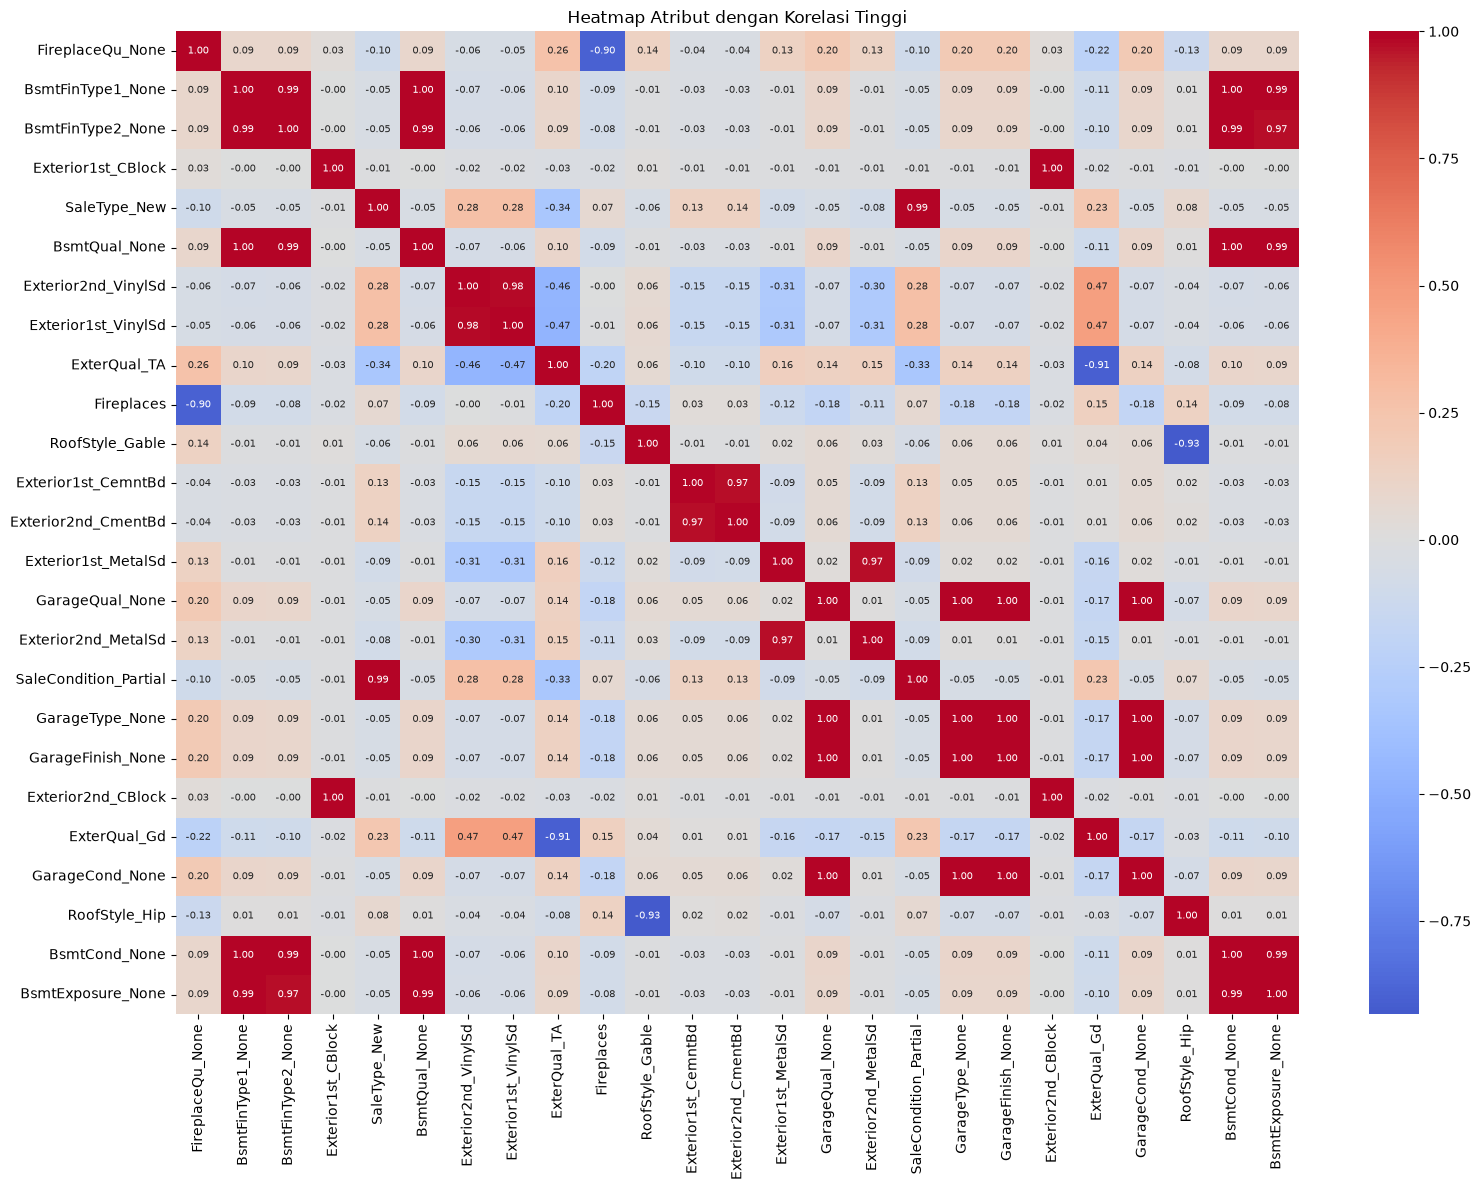

In [31]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    X[fitur_heatmap].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'size': 7}
)

plt.title('Heatmap Atribut dengan Korelasi Tinggi')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.3 Principal Component Analysis (PCA)

PCA digunakan untuk mengurangi jumlah dimensi data dengan membentuk sejumlah principal component yang dapat mempertahankan sebagian besar informasi dari fitur awal. Jumlah komponen ditentukan berdasarkan cumulative explained variance agar reduksi dimensi tetap mempertahankan informasi yang cukup dari dataset.

In [ ]:
pca_awal = PCA()
pca_awal.fit(X_reduced)

cumulative_variance = np.cumsum(pca_awal.explained_variance_ratio_)

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Jumlah fitur sebelum PCA:", X_reduced.shape[1])
print("Jumlah komponen untuk 95% variansi:", n_components_95)

Jumlah fitur sebelum PCA: 228
Jumlah komponen untuk 95% variansi: 66


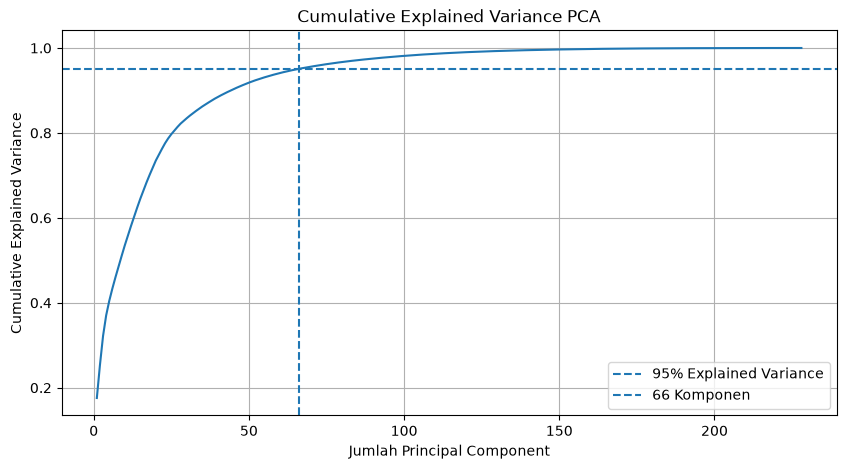

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Explained Variance'
)

plt.axvline(
    x=n_components_95,
    linestyle='--',
    label=f'{n_components_95} Komponen'
)

plt.xlabel('Jumlah Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance PCA')
plt.legend()
plt.grid()
plt.show()

In [35]:
pca = PCA(n_components=n_components_95)

X_pca = pca.fit_transform(X_reduced)

print("Ukuran sebelum PCA:", X_reduced.shape)
print("Ukuran setelah PCA :", X_pca.shape)
print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Ukuran sebelum PCA: (1460, 228)
Ukuran setelah PCA : (1460, 66)
Total explained variance: 0.9507210330024067


## 6. Ringkasan Hasil Praproses

Proses praproses dilakukan pada dataset House Prices yang awalnya terdiri dari 1.460 baris dan 81 atribut. Atribut dengan proporsi missing value lebih dari 50% dihapus, sedangkan missing value yang tersisa ditangani sesuai dengan karakteristik masing-masing atribut hingga tidak terdapat nilai yang hilang. Outlier pada atribut numerik terpilih ditangani menggunakan metode IQR capping untuk mengurangi pengaruh nilai ekstrem tanpa menghapus observasi.

Pada tahap transformasi, atribut numerik distandarisasi menggunakan StandardScaler dan atribut kategoris dikonversi menggunakan one-hot encoding sehingga jumlah atribut menjadi 245. Analisis korelasi kemudian digunakan untuk mengurangi fitur yang sangat berkorelasi, sehingga jumlah fitur yang digunakan berkurang dari 243 menjadi 228. Selanjutnya, PCA menghasilkan 66 principal component yang mampu mempertahankan sekitar 95,07% variasi informasi. Dataset akhir terdiri dari 1.460 baris dan 68 kolom, tanpa missing value maupun data duplikat.